In [1]:
print("Hello WOrld")

Hello WOrld


In [42]:
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient
from langchain_ollama import OllamaEmbeddings
from langchain.tools import tool
from langchain.agents import create_agent

import sys
from pathlib import Path
cwd = Path.cwd()
for candidate in (cwd, cwd.parent):
    if (candidate / "helpers" / "common.py").exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))
        break


from helpers.common import together_ai_llm, langfuse, langfuse_handler

QDRANT_BASE_URL = "http://localhost:6333"
QDRANT_COLLECTION_NAME = "langchain_ollama"

OLLAMA_EMBEDDING_MODEL = "nomic-embed-text:latest"
OLLAMA_BASE_URL = "http://localhost:11434/"


sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")
dense_embeddings = OllamaEmbeddings(
    model=OLLAMA_EMBEDDING_MODEL,
    base_url=OLLAMA_BASE_URL
)



In [17]:
client = QdrantClient(
  url=QDRANT_BASE_URL
)
lo = client.get_collection(collection_name="langchain_ollama")
vector_store = QdrantVectorStore(
    client=client,
    collection_name= QDRANT_COLLECTION_NAME,
    embedding=dense_embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse"  
)

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs = {"k": 5})

In [19]:
retriever.invoke("Creatine")

[Document(metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset/health supplements/3.health_supplements_side_effects.pdf', 'file_path': 'rag-dataset/health supplements/3.health_supplements_side_effects.pdf', 'total_pages': 11, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T14:37:42+00:00', 'trapped': '', 'modDate': 'D:20241021143742Z', 'creationDate': '', 'page': 1, '_id': '1fdc43f2-71b4-4f40-8609-9019409febc8', '_collection_name': 'langchain_ollama'}, page_content='Author Manuscript\nAuthor Manuscript\nAuthor Manuscript\nAuthor Manuscript'),
 Document(metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset/gym supplements/2. High Prevalence of Supplement Intake.pdf', 'file_path': 'rag-dataset/gym supplements/2. High Prevalence of Supplement Intake.pdf', 'total_pages': 11, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate

### Define the Tool (Retrieval)

In [33]:
@tool
def retrieve_context(query: str):
    """
    Retrieve relevant information for health related queries from the document to answer the query.
    """
    print(f"🔍 Searching: '{query}'")
    
    docs = vector_store.similarity_search(query, k=5)
    
    content = "---\n\n".join(
        f"Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content}"
        for doc in docs
    )
    
    print(f"✓ Found {len(docs)} relevant chunks")
    return content


In [34]:
result = retrieve_context.invoke("Creatine")

🔍 Searching: 'Creatine'
✓ Found 5 relevant chunks


In [35]:
print(result)

Source: rag-dataset/health supplements/3.health_supplements_side_effects.pdf (Page 1): Author Manuscript
Author Manuscript
Author Manuscript
Author Manuscript---

Source: rag-dataset/gym supplements/2. High Prevalence of Supplement Intake.pdf (Page 8): and strength gain among men. We detected more prevalent protein and creatine supplementation
among younger compared to older ﬁtness center users, whereas the opposite was found for vitamin
supplementation. Other authors made similar observations [23] and it might reﬂect the diﬀerent
training goals among age groups, i.e., more focus on strength and muscles among the younger and
more focus on health among the older age groups.
Comparable to other studies [4], we detected a positive correlation between training frequency
and supplement usage. Nevertheless, the correlation is weak and is deﬁnitely not a predictor at the
individual level. The subject with the highest supplement intake of 100 weekly servings was training
only once a week.---



### RAG AGENT

In [40]:
tools = [retrieve_context]

system_prompt = """You are a research assistant with a document retrieval tool.

                    Tool:
                    - retrieve_context: Search the document for the health related question

                    Cite page numbers and reference document while writing the answer and be thorough."""

rag_agent = create_agent(
  model=together_ai_llm,
  tools=tools,
  system_prompt=system_prompt
)

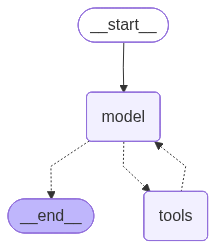

In [41]:
rag_agent

In [43]:
result = rag_agent.invoke({'messages': "What is the use of BCAA?"}, 
config={"callbacks": [langfuse_handler], "run_name": "agentic-rag"},
)

🔍 Searching: 'BCAA use'
✓ Found 5 relevant chunks
🔍 Searching: 'BCAA use'
✓ Found 5 relevant chunks
🔍 Searching: 'BCAA'
🔍 Searching: 'branched chain amino acids use'
✓ Found 5 relevant chunks
✓ Found 5 relevant chunks


In [51]:
ai_message = result['messages'][-1]
print(ai_message.content)

The fetched content confirms use of BCAA. Provide answer with citations.**Branched‑Chain Amino Acids (BCAAs)** – the essential amino acids *leucine, isoleucine,* and *valine* – have been studied for a number of health‑related functions, especially in athletes, the elderly, and people in catabolic states. Below is a concise, evidence‑based summary of the most commonly cited uses, along with the source pages from the documents you provided.

---

### 1. **Stimulate Muscle Protein Synthesis and Aid Post‑Exercise Recovery**  
*Why it matters:* Leucine activates the mTOR signaling pathway that drives muscle protein synthesis. All three BCAAs together help reduce exercise‑induced muscle protein breakdown.  
*Evidence:* **Sanz et al. (2024)** explain that “BCAAs are stored directly in muscles and serve as the raw materials needed to build new muscle” and contribute to “strengthening muscles and alleviating post‑workout soreness”【1†Page 1】.  

**Practical tip:** 5–10 g of BCAAs around training

In [54]:
## Streaming
def ask(question: str):
    print(f"\n{'='*60}")
    print(f"Sawaaal: {question}")
    print('='*60)
    
    for event in rag_agent.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = event["messages"][-1]
        
        # Tool Call
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print("Tool Call: ")
                print(f"\n🔧 Using: {tc['name']} with {tc['args']}")
        
        # Final Answer
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")

In [55]:
ask("how to gain muscle mass?")



Sawaaal: how to gain muscle mass?

💬 Answer:
how to gain muscle mass?
Tool Call: 

🔧 Using: retrieve_context with {'query': 'gain muscle mass'}
🔍 Searching: 'gain muscle mass'
✓ Found 5 relevant chunks

💬 Answer:
Source: rag-dataset/gym supplements/1. Analysis of Actual Fitness Supplement.pdf (Page 0): acids than traditional protein sources. Its numerous benefits have made it a popular choice
for snacks and drinks among consumers [3]. Another widely embraced supplement is
caffeine, which is found in many sports and food supplements. Caffeine reduces perceived
effort, minimizes fatigue and pain, and proves to be effective for endurance and high-
intensity activities, which is the choice of consumers [4].
Creatine monohydrate is another well-known supplement used to gain muscle mass
and support performance and recovery. It is known not to increase fat mass and remains
effective even when taken in recommended doses [5]. Despite its popularity in the fitness
Foods 2024, 13, 1424. https://

In [56]:
ask("Tell me 3 facts about the Earth")


Sawaaal: Tell me 3 facts about the Earth

💬 Answer:
Tell me 3 facts about the Earth

💬 Answer:
**Three interesting facts about Earth**

1. **The only known planet with liquid water on its surface.**  
   Earth’s oceans cover about 71 % of the planet’s surface, providing the essential environment for life as we know it. The presence of liquid water is rare in the Solar System and is a key factor that makes Earth habitable.  

2. **It has a dynamic magnetic field.**  
   The planet’s liquid iron core generates a magnetic field that shields the surface from solar radiation and charged particles. This field protects the atmosphere and biological life from harmful cosmic rays and facilitates navigation for many species, including humans.  

3. **It supports a highly diverse and complex biosphere.**  
   Earth hosts billions of species, ranging from microscopic microbes to the largest mammals. Its varied climates—from tropical rainforests to polar tundra—support a vast array of ecosystems, 